## 1. Import Libraries

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from matplotlib import pyplot as plt
from sklearn.metrics import accuracy_score, precision_score
import shap

Set a random variable for repreducability of the results


In [48]:
random_var=2026

## 2. Read Data

Define a variable to where files are saved on the pc

In [49]:
path_to_files = "https://raw.github.com/jan-source/course_business_analytics_students/main/teaching_cases/case_2_bi_report/data"

### Load Transactions

In [50]:
transactions_part_a = pd.read_excel(f'{path_to_files}/procurement_transactions_part_a.xlsx')

Load part B of the transactions dataset

In [51]:
transactions_part_b = pd.read_excel(f'{path_to_files}/procurement_transactions_part_b.xlsx')

Merge both transaction parts on the 'id' column

In [52]:
transactions = pd.merge(transactions_part_a, transactions_part_b, on='id', how='left')

Show the first rows of the merged transactions dataset

In [53]:
transactions.head()

,supplier_code,material_code,warehouse_code,logistic_partner_code,id,order_date,requested_date,received_date,quantity,price
0,14,c_2,2,6,be97db17-13c5-45b0-a874-4ec09e3333f3,2020-06-05,2020-06-15,2020-06-20 07:00:00,750,3.742660
1,14,c_2,7,6,d1f81ead-a36c-4aa2-af6d-19e29a2472ad,2023-12-28,2024-01-09,2024-01-10 03:00:00,750,7.382834
2,10,c_2,4,6,85f25b81-292a-4097-8d87-6f1b57315ed3,2020-09-07,2020-09-26,2020-09-30 04:00:00,250,5.038926
3,4,c_0,6,6,7fa2cf28-23a3-4029-aa47-d9d4bbc8570b,2023-03-30,2023-04-17,2023-04-16 01:00:00,500,43.626411
4,4,c_0,3,6,48207d3f-134c-4703-a425-61b2f08c65fa,2020-03-29,2020-04-17,2020-04-16 07:00:00,250,30.163969


<div style="background-color:#fff3bf; border-left:6px solid #f08c00; padding:10px 12px; border-radius:4px;color:black">
<strong>Important:</strong> Currently Python will use 00:00:00 for each requested date, resulting in more late deliveries than in the dashboard, if we want to avoid this we could convert the timestampe to a date:
</div>

In [54]:
transactions['received_date'] = transactions['received_date'].dt.date

Create the target variable: a transaction is late if the received date is after the requested date

In [55]:
transactions['late'] = transactions['requested_date'] < transactions['received_date']

Show the proportion (share) of late transactions

In [56]:
transactions['late'].mean()

np.float64(0.33144)

Show the first rows of transactions including the new late flag

In [57]:
transactions.head()

,supplier_code,material_code,warehouse_code,logistic_partner_code,id,order_date,requested_date,received_date,quantity,price,late
0,14,c_2,2,6,be97db17-13c5-45b0-a874-4ec09e3333f3,2020-06-05,2020-06-15,2020-06-20,750,3.742660,True
1,14,c_2,7,6,d1f81ead-a36c-4aa2-af6d-19e29a2472ad,2023-12-28,2024-01-09,2024-01-10,750,7.382834,True
2,10,c_2,4,6,85f25b81-292a-4097-8d87-6f1b57315ed3,2020-09-07,2020-09-26,2020-09-30,250,5.038926,True
3,4,c_0,6,6,7fa2cf28-23a3-4029-aa47-d9d4bbc8570b,2023-03-30,2023-04-17,2023-04-16,500,43.626411,False
4,4,c_0,3,6,48207d3f-134c-4703-a425-61b2f08c65fa,2020-03-29,2020-04-17,2020-04-16,250,30.163969,False


Total Transactions which are late

In [58]:
transactions['late'].sum()

np.int64(8286)

Extract Requested Month and weekday

In [59]:
transactions['requested_month'] = transactions['requested_date'].dt.month
transactions['requested_weekday'] = transactions['requested_date'].dt.weekday

One-hot encode categorical features (supplier, material, warehouse, month, weekday) using dummy variables

In [60]:
transactions_with_dummies = pd.get_dummies(transactions, columns=['supplier_code', 'material_code', 'warehouse_code', 'requested_month', 'requested_weekday'])

#### Define the features (x-Variables)

In [61]:

features = (
            ['quantity', 'price'] + 
            [col for col in transactions_with_dummies.columns if col.startswith('supplier_code_')] +
            [col for col in transactions_with_dummies.columns if col.startswith('material_code_')] + 
            [col for col in transactions_with_dummies.columns if col.startswith('warehouse_code_')] +
            [col for col in transactions_with_dummies.columns if col.startswith('requested_month_')] +
            [col for col in transactions_with_dummies.columns if col.startswith('requested_weekday_')]
            )

Print the full list of selected feature names

In [62]:
features

['quantity',
 'price',
 'supplier_code_1',
 'supplier_code_2',
 'supplier_code_3',
 'supplier_code_4',
 'supplier_code_5',
 'supplier_code_6',
 'supplier_code_7',
 'supplier_code_8',
 'supplier_code_9',
 'supplier_code_10',
 'supplier_code_11',
 'supplier_code_12',
 'supplier_code_13',
 'supplier_code_14',
 'supplier_code_15',
 'material_code_c_0',
 'material_code_c_1',
 'material_code_c_2',
 'material_code_c_3',
 'material_code_c_4',
 'material_code_c_5',
 'material_code_c_6',
 'material_code_c_7',
 'warehouse_code_1',
 'warehouse_code_2',
 'warehouse_code_3',
 'warehouse_code_4',
 'warehouse_code_5',
 'warehouse_code_6',
 'warehouse_code_7',
 'requested_month_1',
 'requested_month_2',
 'requested_month_3',
 'requested_month_4',
 'requested_month_5',
 'requested_month_6',
 'requested_month_7',
 'requested_month_8',
 'requested_month_9',
 'requested_month_10',
 'requested_month_11',
 'requested_month_12',
 'requested_weekday_0',
 'requested_weekday_1',
 'requested_weekday_2',
 'request

#### Clean Data for missing values

In [63]:
transactions_with_dummies.dropna(subset=features, inplace=True)

### Test / Train split


In [64]:
X_train, X_test, y_train, y_test = train_test_split(
    transactions_with_dummies[features], 
    transactions_with_dummies['late'],
    test_size=0.2, 
    random_state=random_var
)

### Random Forest

Documentation of the Random Forest Function from SKLEARN
https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html

In [65]:
rf = RandomForestClassifier(n_estimators=50, random_state=random_var, min_samples_split=40)

Fit the deeper Random Forest on the training data

In [66]:
rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",50
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",40
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

Calculate predictions on the test dataset for the deeper Random Forest

In [67]:
rf_test_predictions = rf.predict(X_test)

Calculate predictions on the training dataset for the deeper Random Forest

In [68]:
rf_train_predictions = rf.predict(X_train)

Accuracy score on the training dataset for the deeper Random Forest

In [69]:
accuracy_score(y_true=y_train, y_pred=rf_train_predictions)

0.8343989769820972

Accuracy score on the test dataset for the deeper Random Forest

In [70]:
accuracy_score(y_true=y_test, y_pred=rf_test_predictions)

0.799628079962808

Precision score on the test dataset for the deeper Random Forest

In [71]:
precision_score(y_true=y_test, y_pred=rf_test_predictions)

0.7725

## Explainable AI

### Feature Importance

In [72]:
# Get feature importance from the Random Forest model
importances = rf.feature_importances_

#### Sort features by importance (descending)

In [73]:
indices = np.argsort(importances)[::-1]  

#### Create a DataFrame to store feature names and their importance

In [74]:
# Create a DataFrame to store feature names and their importance
feature_importance_df = pd.DataFrame({
    'Feature': [features[i] for i in indices],
    'Importance': [importances[i] for i in indices]
})


In [75]:
feature_importance_df.head(10)

,Feature,Importance
0,price,0.195670
1,supplier_code_14,0.121744
2,quantity,0.112283
3,warehouse_code_7,0.068294
4,material_code_c_0,0.044098
5,supplier_code_7,0.034837
6,requested_month_12,0.034555
7,requested_weekday_5,0.034085
8,requested_month_7,0.029305
9,supplier_code_9,0.021556


#### Plot the top 20 most important features

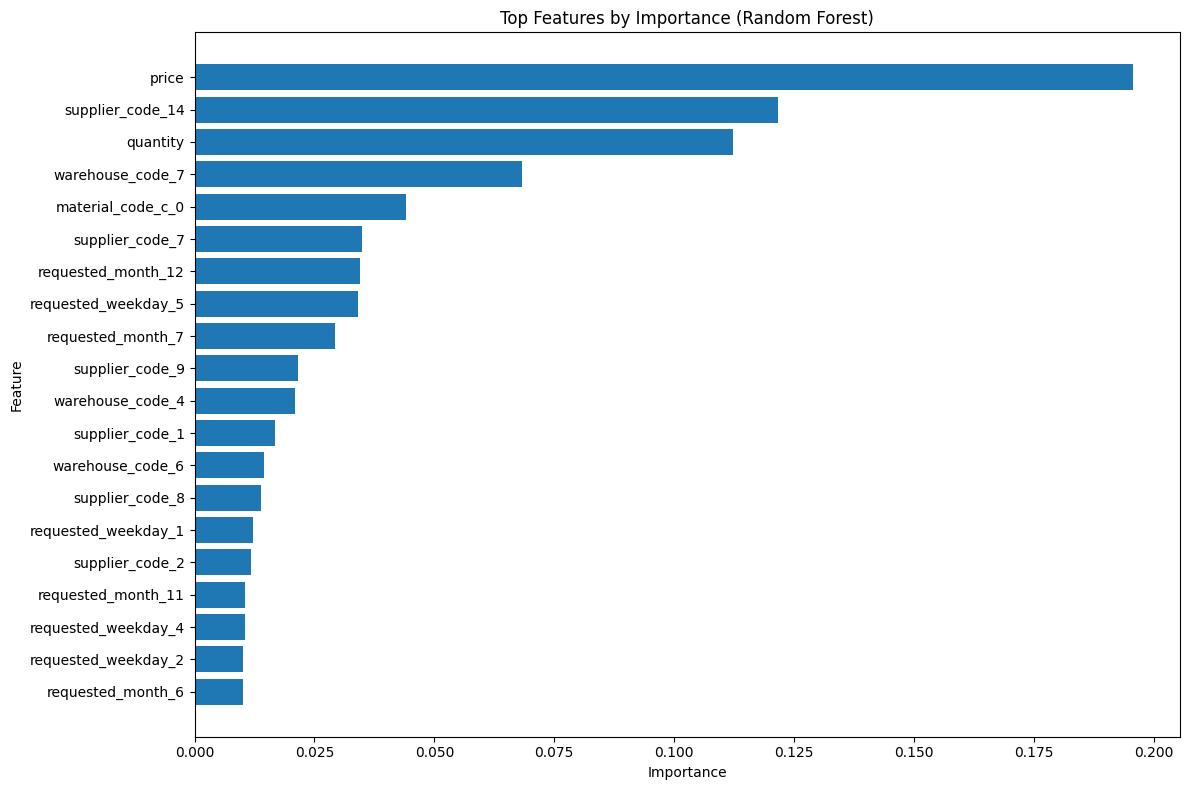

In [76]:
n_features = 20 
top_features = feature_importance_df.head(n_features)

plt.figure(figsize=(12, 8))
plt.barh(top_features['Feature'][::-1], top_features['Importance'][::-1])
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Top Features by Importance (Random Forest)')
plt.tight_layout()
# plt.savefig('rf_feature_importance.png', dpi=300) # Optional saving as image
plt.show()

Comparing with graph similar to power bi dashbaord

<Axes: xlabel='supplier_code'>

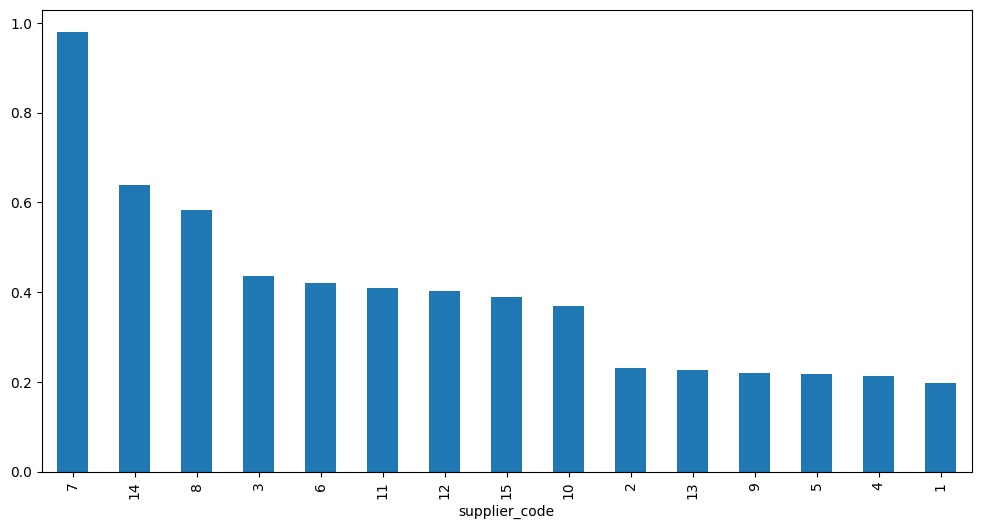

In [77]:
transactions.groupby('supplier_code')['late'].mean().sort_values(ascending=False).plot(kind='bar', figsize=(12, 6))

### Create explainer for Random Forest

In [78]:
explainer_rf = shap.TreeExplainer(
                rf, 
                model_output='probability', 
                data=X_test.astype(int).values
                )

#### Sample 100 observations from the test sample (the more observations we use the longer the calculations will take)

In [79]:
sample = X_test.sample(100, random_state=random_var)

Calculate the SHAP values for the test set (can take some time)

In [80]:
shap_values_rf = explainer_rf.shap_values(sample)

In [81]:
shap_values_rf.shape

(100, 51, 2)

Create Summary Plot


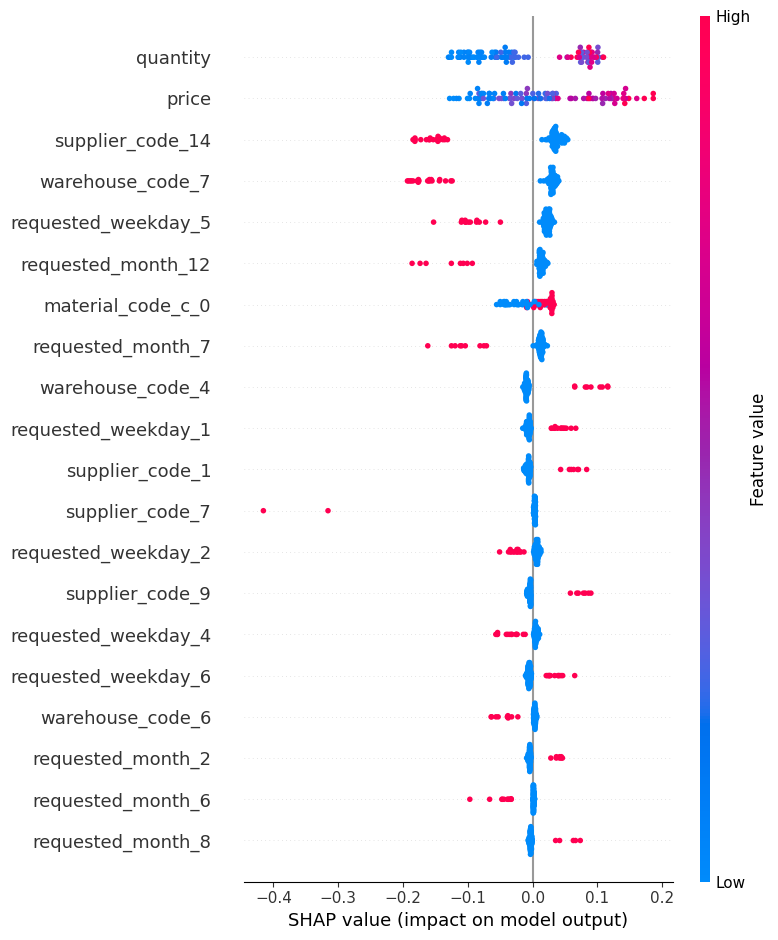

In [82]:
shap.summary_plot(
          shap_values_rf[..., 0], 
          sample, 
          feature_names=features, 
          max_display=20
        )

### Explain a single observation

In [83]:
shap.initjs()

Set observations

In [84]:
obs = 1

Get Prediction from the random forest for this observation

In [85]:
rf.predict_proba(sample.iloc[obs:obs+1])

array([[0.77856073, 0.22143927]])

Verify average probability for being late from shap

In [86]:
explainer_rf.expected_value[1]

np.float64(0.35154560905596066)

In [87]:
shap.force_plot(explainer_rf.expected_value[1],  shap_values_rf[obs][:, 1], X_test.iloc[obs,:][features])